In [12]:
import sys,copy,os
sys.path.append(os.getcwd()+"/../neuronVis")
import json

import IONData as IONData 
import BrainRegion as BR 

import Visual as nv
import NeuronProcess
import RegionProcess
import SwcLoader
import GeometryAdapter

import numpy as np

In [13]:
br = BR.BrainRegion()
br.praseJson()
SSbr= br.getRegion('SS')
MObr= br.getRegion('MO')
mergebr= RegionProcess.mergeRegion(SSbr,MObr)
# get neuron list
f=open('../resource/paper1figure7list.json', encoding='gbk')
paper1figure7list=[]
paper1figure7list = json.load(f)
print(paper1figure7list)

loading nrrd ... 
loaded only left brain g:\workspace\neuron-vis\figures/../neuronVis/../resource/strcture/structure_453.nrrd
loading nrrd ... 
loaded only left brain g:\workspace\neuron-vis\figures/../neuronVis/../resource/strcture/structure_500.nrrd
[{'sampleid': 'sample', 'name': 'AA0586.swc'}, {'sampleid': 'sample', 'name': 'AA0485.swc'}, {'sampleid': 'sample', 'name': 'AA0451.swc'}, {'sampleid': 'sample', 'name': 'AA0366.swc'}, {'sampleid': 'sample', 'name': 'AA0364.swc'}, {'sampleid': 'sample', 'name': 'AA0350.swc'}, {'sampleid': 'sample', 'name': 'AA0349.swc'}, {'sampleid': 'sample', 'name': 'AA0348.swc'}, {'sampleid': 'sample', 'name': 'AA0347.swc'}, {'sampleid': 'sample', 'name': 'AA0346.swc'}, {'sampleid': 'sample', 'name': 'AA0345.swc'}, {'sampleid': 'sample', 'name': 'AA0343.swc'}, {'sampleid': 'sample', 'name': 'AA0340.swc'}, {'sampleid': 'sample', 'name': 'AA0339.swc'}, {'sampleid': 'sample', 'name': 'AA0338.swc'}, {'sampleid': 'sample', 'name': 'AA0337.swc'}, {'sampleid'

In [81]:
iondata=IONData.IONData()
centroidList=[]
for neuron in paper1figure7list:
    swc = iondata.getNeuronByID(neuron['sampleid'], neuron['name'])
    neuronTree = SwcLoader.NeuronTree()
    neuronTree.readSWC(swc)
    centroid = NeuronProcess.getCentroid(neuronTree,mergebr)
    centroidList.append([np.array(neuronTree.root.xyz),centroid])

exist  g:\workspace\neuron-vis\figures/../neuronVis/../resource/swc/sample/AA0586.swc
maxindex: 5524
exist  g:\workspace\neuron-vis\figures/../neuronVis/../resource/swc/sample/AA0485.swc
maxindex: 1872
exist  g:\workspace\neuron-vis\figures/../neuronVis/../resource/swc/sample/AA0451.swc
maxindex: 5796
exist  g:\workspace\neuron-vis\figures/../neuronVis/../resource/swc/sample/AA0366.swc
maxindex: 4498
exist  g:\workspace\neuron-vis\figures/../neuronVis/../resource/swc/sample/AA0364.swc
maxindex: 3656
exist  g:\workspace\neuron-vis\figures/../neuronVis/../resource/swc/sample/AA0350.swc
maxindex: 4791
exist  g:\workspace\neuron-vis\figures/../neuronVis/../resource/swc/sample/AA0349.swc
maxindex: 4543
exist  g:\workspace\neuron-vis\figures/../neuronVis/../resource/swc/sample/AA0348.swc
maxindex: 4131
exist  g:\workspace\neuron-vis\figures/../neuronVis/../resource/swc/sample/AA0347.swc
maxindex: 4984
exist  g:\workspace\neuron-vis\figures/../neuronVis/../resource/swc/sample/AA0346.swc
maxin

In [18]:
point=RegionProcess.getIntersectionFacePoints(SSbr,MObr)


[3386.06417221 2738.3677587  3892.3201525 ]
[3842.74265727 2790.78667707 3232.01223584]
[3446.49255479 2679.21878629 3498.49162945]
[3238.31762077 2541.271877   3678.2660034 ]
[4471.08564876 3378.25462236 2554.78540414]
[3313.94828504 2736.54001162 3683.33569337]
[4495.41950121 3355.0416571  2332.1261084 ]
[3653.79948546 3127.26763749 2802.90121839]
[4123.91871452 2299.66264883 3598.0748131 ]
[3103.42179165 2424.23905711 4027.75604016]
[3840.42016232 2647.07891598 3187.8105466 ]
[4414.55507984 3292.16453472 2280.65145905]
[3377.81749744 2892.24641026 3118.3384    ]
[4036.19643657 3146.66303703 2601.65713836]
[3945.46743639 2638.37758105 3164.36809209]
[3568.09814079 2810.03622356 3604.16196056]
[3714.37396172 2077.0718671  3799.53440564]
[3968.53522845 2497.96083694 3521.3148905 ]


In [82]:
centroidListtemp=copy.deepcopy(centroidList)
for centroid in centroidListtemp:
    print(centroid)
    mindist=10000
    
    for p in point:
        dist= np.sqrt(np.sum(np.square(np.array(centroid[1])-p)))
        mindist =dist if dist<mindist else mindist
    centroid.append(np.array([mindist,0,0]))
    print(centroid)
    

[array([6814.8477, 4458.618 , 4711.323 ], dtype=float32), array([3386.06417221, 2738.3677587 , 3892.3201525 ])]
[array([6814.8477, 4458.618 , 4711.323 ], dtype=float32), array([3386.06417221, 2738.3677587 , 3892.3201525 ]), array([1287.49327506,    0.        ,    0.        ])]
[array([6736.87  , 4406.8804, 4542.037 ], dtype=float32), array([3842.74265727, 2790.78667707, 3232.01223584])]
[array([6736.87  , 4406.8804, 4542.037 ], dtype=float32), array([3842.74265727, 2790.78667707, 3232.01223584]), array([499.79244051,   0.        ,   0.        ])]
[array([6791.2236, 4667.1494, 4802.8584], dtype=float32), array([3446.49255479, 2679.21878629, 3498.49162945])]
[array([6791.2236, 4667.1494, 4802.8584], dtype=float32), array([3446.49255479, 2679.21878629, 3498.49162945]), array([981.68573468,   0.        ,   0.        ])]
[array([6725.3154, 4492.541 , 4902.9453], dtype=float32), array([3238.31762077, 2541.271877  , 3678.2660034 ])]
[array([6725.3154, 4492.541 , 4902.9453], dtype=float32), ar

[6.68867676 6.85796289 6.5971416  6.49705469 6.50188477 6.56464844
 6.85459082 6.64037451 7.12077539 6.637104   6.62553418 6.80790723
 6.90778516 6.80455029 6.92178174 6.62198779 6.95643604 6.81556104] [1.28749328 0.49979244 0.98168573 1.28161366 0.36618368 1.19368271
 0.54194929 0.32019857 0.57058704 1.6433703  0.52545375 0.52335533
 0.74361287 0.05907933 0.44391065 0.95038808 1.05217981 0.67625762]


d:\ProgramData\Anaconda3\envs\neuronVis\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ProgramData\Anaconda3\envs\neuronVis\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ProgramData\Anaconda3\envs\neuronVis\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


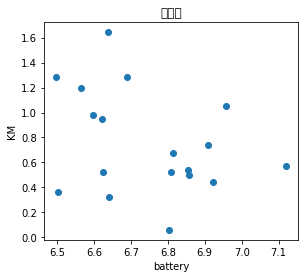

In [91]:
import matplotlib.pyplot as plt
temp =np.array(centroidListtemp)
x=11.4-temp[:,0,2]/1000
y=temp[:,2,0]/1000
print(x,y)

# print(x)
# 画出数据的散点图
fig = plt.figure()
fig.set_size_inches(10, 4)   # 整个绘图区域的宽度10和高度4
ax = fig.add_subplot(1, 2, 1)  # 整个绘图区分成一行两列，当前图是第一个。
# 画出原始数据的散点图。
ax.set_title("散点图")
ax.set_xlabel("battery")
ax.set_ylabel("KM")
ax.scatter(x, y)
plt.show()


In [15]:



# render
neuronvis = nv.neuronVis()
# neuronvis.addNeuronByList(paper1figure7list)
neuronvis.render.setLookAt((-10000,-10000,-10000),(0,0,0),(0,1,0))
neuronvis.render

ga = GeometryAdapter.GeometryAdapter()
index=0
for p in centroidList:
	ga.geometry.addPoint(p.tolist())
	ga.geometry.addIndex(index)
	index=index+1
ga.geometry.drawModel='points'
neuronvis.render.addGeometry(ga.geometry)
neuronvis.render

# neuronvis.render.savepng('../resource/test3.png')
nv.app.run()

RFBOutputContext()